# Customer Engagement & Product Utilization Analytics for Retention Strategy
**Prepared by: Aniket Chakraborty**

This notebook reproduces data validation, EDA, segmentation, KPI computation and churn-model evaluation used by the Streamlit application.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from analytics import load_data, add_features, calculate_kpis, grouped_metrics
from modeling import train_and_evaluate, feature_importance

DATA_PATH = Path('data/European_Bank.csv')
df = load_data(DATA_PATH)
analytics_df = add_features(df)
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. Data Validation

In [2]:
validation = pd.Series({
    'Rows': len(df),
    'Columns': len(df.columns),
    'Missing values': int(df.isna().sum().sum()),
    'Duplicate rows': int(df.duplicated().sum()),
    'Duplicate customer IDs': int(df.CustomerId.duplicated().sum()),
})
validation

Rows                      10000
Columns                      14
Missing values                0
Duplicate rows                0
Duplicate customer IDs        0
dtype: int64

## 2. KPI Summary

In [3]:
pd.Series(calculate_kpis(analytics_df))

customers                          10000.000000
churn_rate                             0.203700
retention_rate                         0.796300
active_rate                            0.515100
engagement_retention_ratio             0.857309
avg_products                           1.530200
product_depth_index                    0.382550
high_balance_disengagement_rate        0.498800
credit_card_stickiness_score           0.798157
relationship_strength_index           57.510770
dtype: float64

## 3. Churn by Geography

,Geography,Customers,ChurnRate,RetentionRate,ActiveRate,AverageProducts,AverageBalance,RelationshipStrength
0,France,5014,0.161548,0.838452,0.516753,1.530913,62092.636516,56.898783
1,Germany,2509,0.324432,0.675568,0.497409,1.519729,119730.116134,58.847310
2,Spain,2477,0.166734,0.833266,0.529673,1.539362,61818.147763,57.395761


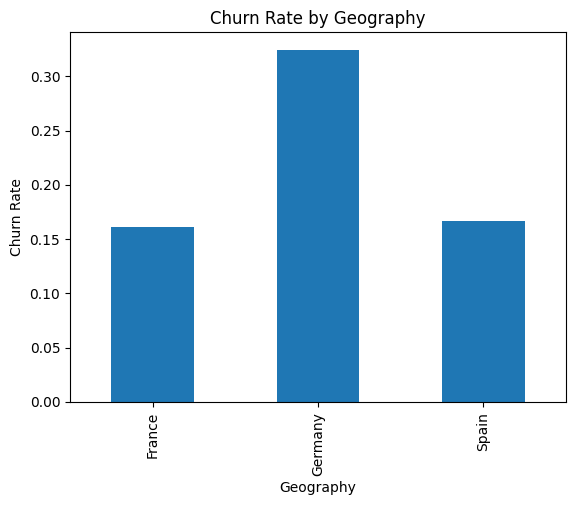

In [4]:
geo = grouped_metrics(analytics_df, 'Geography')
display(geo)
geo.set_index('Geography')['ChurnRate'].plot(kind='bar', title='Churn Rate by Geography')
plt.ylabel('Churn Rate')
plt.show()

## 4. Engagement Classification

In [5]:
engagement = grouped_metrics(analytics_df, 'EngagementSegment')
display(engagement.sort_values('ChurnRate', ascending=False))

,EngagementSegment,Customers,ChurnRate,RetentionRate,ActiveRate,AverageProducts,AverageBalance,RelationshipStrength
3,Inactive High-Balance,1247,0.304731,0.695269,0.0,1.381716,148857.679743,42.641700
2,Inactive Disengaged,3602,0.255969,0.744031,0.0,1.573848,52304.016316,38.265075
1,Active Low-Product,2563,0.189231,0.810769,1.0,1.000000,98902.019317,68.180609
0,Active Engaged,2588,0.096600,0.903400,1.0,2.066074,53071.261190,80.894822


## 5. Product Utilization

,NumOfProducts,Customers,ChurnRate,RetentionRate,ActiveRate,AverageProducts,AverageBalance,RelationshipStrength
0,1,5084,0.277144,0.722856,0.504131,1.0,98551.870614,51.009854
1,2,4590,0.075817,0.924183,0.532898,2.0,51879.145813,65.710806
2,3,266,0.827068,0.172932,0.424812,3.0,75458.328195,43.884211
3,4,60,1.000000,0.000000,0.483333,4.0,93733.135000,41.463333


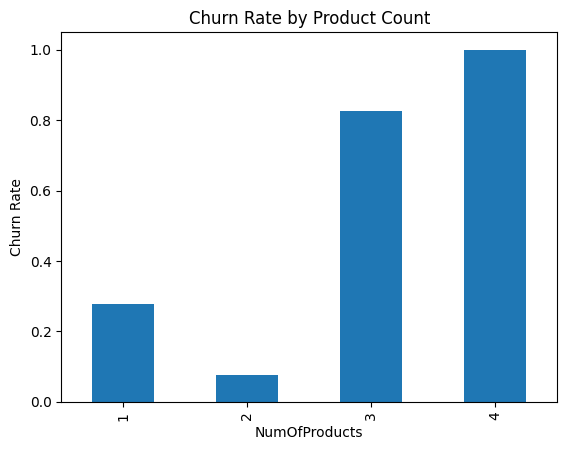

In [6]:
products = grouped_metrics(analytics_df, 'NumOfProducts')
display(products)
products.set_index('NumOfProducts')['ChurnRate'].plot(kind='bar', title='Churn Rate by Product Count')
plt.ylabel('Churn Rate')
plt.show()

## 6. High-Balance Disengagement

In [7]:
threshold = analytics_df.Balance.quantile(.75)
premium = analytics_df[analytics_df.Balance >= threshold]
pd.Series({
    'Premium threshold': threshold,
    'Premium customers': len(premium),
    'Inactive premium share': 1 - premium.IsActiveMember.mean(),
    'Inactive premium churn': premium.loc[premium.IsActiveMember.eq(0), 'Exited'].mean(),
})

Premium threshold         127644.240000
Premium customers           2500.000000
Inactive premium share         0.498800
Inactive premium churn         0.304731
dtype: float64

## 7. Fairness-Aware Churn Model

In [8]:
model, metrics = train_and_evaluate(df)
pd.Series(metrics)

ROC AUC      0.854468
Accuracy     0.843500
Precision    0.608295
Recall       0.648649
F1 Score     0.627824
dtype: float64

In [9]:
feature_importance(model).head(15)

,Feature,Importance
0,Age,0.329507
1,NumOfProducts,0.191588
2,Balance,0.123213
3,EstimatedSalary,0.084917
4,CreditScore,0.084495
5,Tenure,0.049016
6,Geography_Germany,0.037118
7,IsActiveMember_1,0.031792
8,IsActiveMember_0,0.030522
9,Geography_France,0.014383


## 8. Recommended Retention Actions

1. Prioritize inactive, high-balance customers for proactive service outreach.
2. Move suitable one-product customers toward a relevant two-product relationship.
3. Investigate the high churn of three- and four-product customers before expanding bundles.
4. Build geography-specific retention pilots, with Germany as the first priority.
5. Use credit-card ownership only as a supporting signal because it has weak standalone separation.
6. Monitor gender outcomes for fairness; do not target interventions solely by gender.